# 02 — ngspice vs analytical

Created with Grok Build

Behavioral LDO (`LT3010_BEHAV`) uses the **external divider**, so R1/R2 and $I_{\mathrm{ADJ}}$ match the closed form. Dynamics (PSRR pole, load-step recovery) are a sanity check — the vendor macromodel in notebook 05 is the dynamics reference.


## Setup — editable BOM and run knobs

This cell is shared by every notebook. It puts `P5V_Regulator/` on `sys.path`
and builds **one** `CircuitParams` object. Change a resistor, capacitor, or
tolerance here and re-run: analytical, SPICE, WC, and MC all follow this object.

**Plot callouts:** each figure cell has an `ann = [dict(...), ...]` list.
Edit `text`, `xy` (data coords of the arrow tip), and `offset=(dx, dy)` in
**points** to nudge a label. Use `xytext=(x, y)` instead of `offset` for data
coordinates. `arrow=False` for a plain label. `ann = []` hides all callouts.

Tolerances are **fractions** (0.01 = 1 %). Figures go to `results/figures/`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/LT3010_5V_Supply")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "p5v_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from p5v_design.params import CircuitParams, ToleranceSpec, format_eng, LdoParams
from p5v_design import analysis, schematic, plots, stability
from p5v_design import plots_wc_mc as pwc
from p5v_design.ldo_model import dropout_v, ignd_a, tj_c, psrr_db, vadj_typical_vs_temp
from dataclasses import replace

# --- EDITABLE BOM ---
# Datasheet TA01, "5V Supply with Shutdown" (LT3010/LT3010-5 Rev. J page 1).
# Fixed 5 V part: SENSE tied to OUT (R1 = 0). No external divider (R2 open).
# Capacitors are the 1 µF parts drawn on that figure. Load is the labeled 50 mA.
# VIN is printed as 5.4 V to 80 V; 12 V is the single-point bias inside that range.
R1 = 0.0             # SENSE shorted to OUT
R2 = 1.0e12          # open — no bottom resistor
CFF = 0.0            # no feedforward capacitor on the fixed part
COUT = 1.0e-6
CIN = 1.0e-6
ESR_OUT = 10e-3      # ceramic assumption, not printed on TA01
ESR_IN = 10e-3
RLOAD = 100.0        # 5 V / 50 mA
R_TOL = 0.01         # 1 %
C_TOL = 0.10         # 10 %
VIN_NOM = 12.0
VIN_MIN = 5.4
VIN_MAX = 80.0
ILOAD_OP = 50e-3
N_MC = 2000
N_SPICE_MC = 40
N_LTSPICE_MC = 40
SKIP_SPICE_WC_MC = False
RUN_LTSPICE_BATCH = True
SPICE_WORKERS = 4
LTSPICE_WORKERS = 4

p = CircuitParams(
    r1=R1, r2=R2, cff=CFF, cout=COUT, cin=CIN,
    esr_out=ESR_OUT, esr_in=ESR_IN, r_load=RLOAD,
    r_tol=ToleranceSpec(R_TOL), c_tol=ToleranceSpec(C_TOL),
)
p = replace(p, op=replace(p.op, vin_nom=VIN_NOM, vin_min=VIN_MIN, vin_max=VIN_MAX,
                           iload_op=ILOAD_OP, r_load=RLOAD))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("gain =", p.gain, "  Vout nom =", analysis.vout_dc(p))
print("SPICE_WORKERS =", SPICE_WORKERS, "  N_MC =", N_MC)


gain = 1.0   Vout nom = 5.0
SPICE_WORKERS = 4   N_MC = 2000


In [2]:
from p5v_design.simulate import find_ngspice, simulate_op, simulate_dc_vin, simulate_dc_i, simulate_ac_psrr

try:
    print("ngspice ready")
    HAVE_SPICE = True
except FileNotFoundError as e:
    print(e)
    HAVE_SPICE = False


ngspice ready


## Operating point

In [3]:
an = analysis.summary_metrics(p)
print("analytical Vout", an["vout"])
if HAVE_SPICE:
    op = simulate_op(p, workdir=ROOT/"results"/"ngspice_nom"/"op",
                     mirror=ROOT/"netlists"/"spice_nom"/"p5v_op.cir")
    print("ngspice nodes", op.nodes)
    vsp = op.nodes.get("out", list(op.nodes.values())[0] if op.nodes else float("nan"))
    print(f"error {1e3*(vsp-an['vout']):.3f} mV")
else:
    print("skip ngspice OP")

analytical Vout 5.0


ngspice nodes {'out': 4.99995, 'v(out)': 4.99995, 'adj': 4.99995, 'v(adj)': 4.99995, 'vin': 12.0, 'v(vin)': 12.0}
error -0.050 mV


## Vin sweep overlay

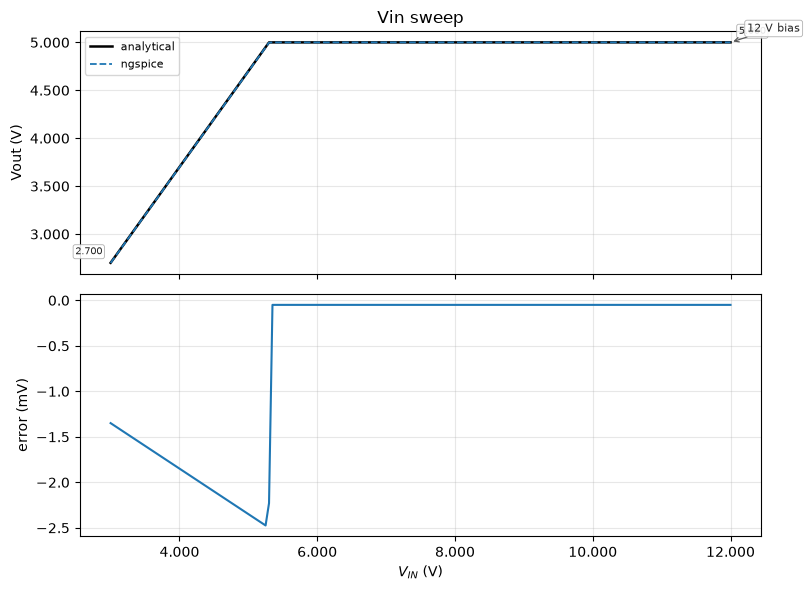

In [4]:
vin, v_an = analysis.vout_vs_vin(p, which_do="typ")
ann = [
    dict(text="12 V bias", xy=(12.0, analysis.vout_dc(p)), offset=(12, 10), arrow=True),
]
if HAVE_SPICE:
    dc = simulate_dc_vin(p, workdir=ROOT/"results"/"ngspice_nom"/"dc_vin",
                         mirror=ROOT/"netlists"/"spice_nom"/"p5v_dc_vin.cir")
    v_sp = np.interp(vin, dc.x, dc.vout)
    plots.plot_overlay_dc(vin, v_an, v_sp, xlabel=r"$V_{IN}$ (V)", title="Vin sweep",
                          annotations=ann, path=FIG/"02_vin_overlay.png")
else:
    plots.plot_vout_vs_vin(vin, v_an, annotations=ann, path=FIG/"02_vin_overlay.png")
plt.show()

## Iload sweep overlay

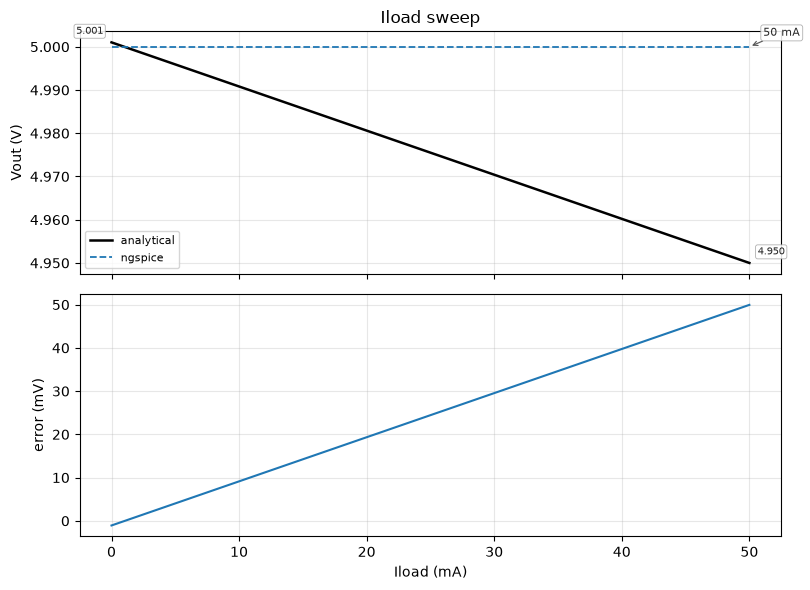

In [5]:
i, vo = analysis.vout_vs_iload(p)
ann = [dict(text="50 mA", xy=(50.0, analysis.vout_dc(p)), offset=(10, 10), arrow=True)]
if HAVE_SPICE:
    dci = simulate_dc_i(p, workdir=ROOT/"results"/"ngspice_nom"/"dc_i",
                        mirror=ROOT/"netlists"/"spice_nom"/"p5v_dc_i.cir")
    # sweep variable is Iload (A)
    v_sp = np.interp(i, dci.x, dci.vout)
    plots.plot_overlay_dc(1e3*i, vo, v_sp, xlabel="Iload (mA)", title="Iload sweep",
                          annotations=ann, path=FIG/"02_i_overlay.png")
else:
    plots.plot_vout_vs_iload(i, vo, annotations=ann, path=FIG/"02_i_overlay.png")
plt.show()

## PSRR — datasheet curve vs behavioral AC

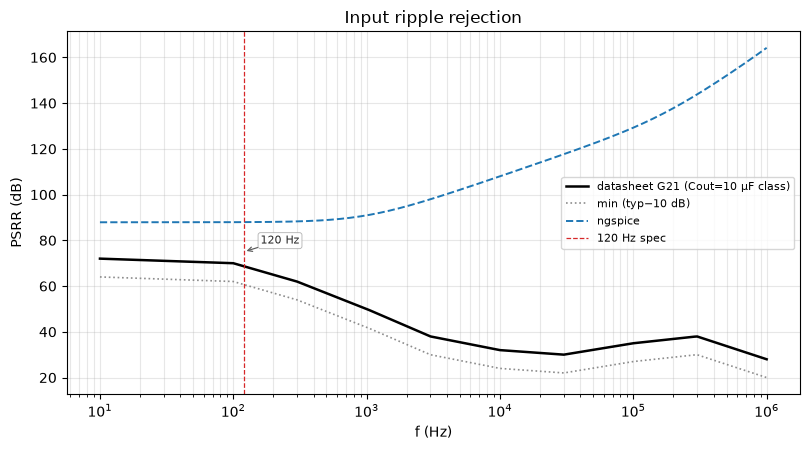

In [6]:
ann = [dict(text="120 Hz", xy=(120, 75), offset=(12, 8), arrow=True)]
if HAVE_SPICE:
    ac = simulate_ac_psrr(p, workdir=ROOT/"results"/"ngspice_nom"/"psrr",
                          mirror=ROOT/"netlists"/"spice_nom"/"p5v_psrr.cir")
    plots.plot_psrr(p, spice_f=ac.f_hz, spice_db=ac.psrr_db, annotations=ann,
                    path=FIG/"02_psrr.png")
else:
    plots.plot_psrr(p, annotations=ann, path=FIG/"02_psrr.png")
plt.show()

## Residual and OP bars (HV_monitor / Opamp notebook 02 style)

PSRR error = ngspice − datasheet G21. OP bars compare closed-form $V_{\mathrm{OUT}}$ to the behavioral OP.

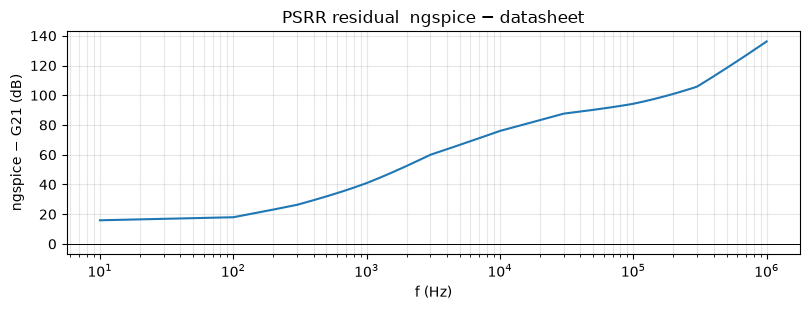

OP error -0.050 mV


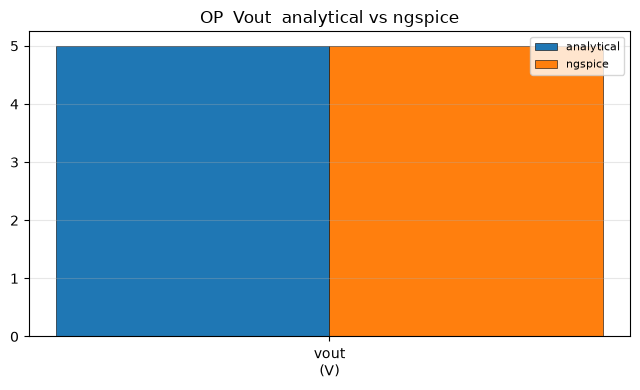

In [7]:
an = analysis.summary_metrics(p)
rows = {"analytical": {"vout": an["vout"]}}
if HAVE_SPICE:
    ac = simulate_ac_psrr(p, workdir=ROOT/"results"/"ngspice_nom"/"psrr")
    f = np.logspace(1, 6, 241)
    ds = psrr_db(f, cout=p.cout)
    sp = np.interp(f, ac.f_hz, ac.psrr_db)
    plots.plot_error_db(
        f, sp - ds, ylabel="ngspice − G21 (dB)",
        title="PSRR residual  ngspice − datasheet",
        path=FIG/"02_psrr_error.png",
    )
    plt.show()
    try:
        vsp = float(op.nodes.get("out", next(iter(op.nodes.values()))))
        rows["ngspice"] = {"vout": vsp}
        print(f"OP error {1e3*(vsp-an['vout']):.3f} mV")
    except NameError:
        print("OP result not in namespace; skip OP bars overlay")
plots.plot_op_compare_bars(
    rows, metrics=("vout",), units={"vout": "V"},
    title="OP  Vout  analytical vs ngspice", path=FIG/"02_op_bars.png",
)
plt.show()